In [24]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [26]:
# Esta celda define la ruta del dataset local.
# Sirve para trabajar en VS Code sin depender de Google Colab.
data_path = 'Datos0..csv'
print(f'Archivo a usar: {os.path.abspath(data_path)}')

Archivo a usar: e:\USFX\6to Semestre\Ia\Ejercicios\Datos0..csv


In [29]:
# Esta celda carga el dataset de regresión y separa datos en x (entradas) y y (salida).
# Sirve para cumplir la consigna con n>=10 y m>=10000 usando 'cnt' como variable objetivo.
df = pd.read_csv(data_path, sep=';')
target_col = 'cnt'
feature_cols = [col for col in df.columns if col != target_col]

x = df[feature_cols].astype(float).values
y = df[target_col].astype(float).values

m = y.size
n = x.shape[1]

In [31]:
# Esta celda muestra una vista rápida del dataframe.
# Sirve para verificar que el archivo se cargó correctamente.
print(df.head())

   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   
2       1   0     1   2        0        6           0           1  0.22   
3       1   0     1   3        0        6           0           1  0.24   
4       1   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  cnt  
0  0.2879  0.81        0.0   16  
1  0.2727  0.80        0.0   40  
2  0.2727  0.80        0.0   32  
3  0.2879  0.75        0.0   13  
4  0.2879  0.75        0.0    1  


In [34]:
# Esta celda imprime ejemplos de x (variables de entrada).
# Sirve para inspeccionar el formato numérico de las características.
print(x[:5])

[[1.     0.     1.     0.     0.     6.     0.     1.     0.24   0.2879
  0.81   0.    ]
 [1.     0.     1.     1.     0.     6.     0.     1.     0.22   0.2727
  0.8    0.    ]
 [1.     0.     1.     2.     0.     6.     0.     1.     0.22   0.2727
  0.8    0.    ]
 [1.     0.     1.     3.     0.     6.     0.     1.     0.24   0.2879
  0.75   0.    ]
 [1.     0.     1.     4.     0.     6.     0.     1.     0.24   0.2879
  0.75   0.    ]]


In [35]:
# Esta celda imprime ejemplos de y (variable objetivo).
# Sirve para validar que 'cnt' se separó correctamente.
print(y[:10])

[16. 40. 32. 13.  1.  1.  2.  3.  8. 14.]


In [38]:
# Esta celda valida el tamaño del problema para la consigna.
# Sirve para confirmar que m>=10000 y n>=10.
print(f'm (ejemplos): {m}')
print(f'n (features): {n}')
print(f'Cumple m>=10000: {m >= 10000}')
print(f'Cumple n>=10: {n >= 10}')

m (ejemplos): 17379
n (features): 12
Cumple m>=10000: True
Cumple n>=10: True


In [39]:
# Esta celda define una función de graficación simple.
# Sirve para visualizar la relación entre una variable y la salida.
def plotData(x_plot, y_plot, xlabel='Feature', ylabel='cnt', title='Datos'):
    fig = pyplot.figure(figsize=(8, 4))
    pyplot.plot(x_plot, y_plot, 'ro', ms=2, mec='k', alpha=0.35)
    pyplot.ylabel(ylabel)
    pyplot.xlabel(xlabel)
    pyplot.title(title)
    pyplot.grid(alpha=0.2)

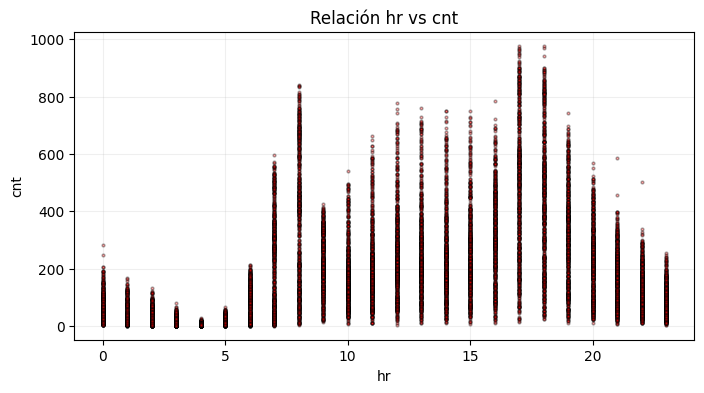

In [42]:
# Esta celda grafica un feature representativo contra y.
# Sirve para una inspección visual inicial del dataset.
plotData(df['hr'].values, y, xlabel='hr', ylabel='cnt', title='Relación hr vs cnt')

In [45]:
# Esta celda normaliza x y agrega el término de sesgo para formar X.
# Sirve para acelerar la convergencia y mantener la estructura clásica del código base.
mu = x.mean(axis=0)
sigma = x.std(axis=0)
sigma[sigma == 0] = 1.0

X_norm = (x - mu) / sigma
X = np.c_[np.ones(m), X_norm]

In [48]:
# Esta celda verifica dimensiones y muestra una fila de x junto con su y correspondiente.
# Sirve para comprobar que los datos están bien alineados antes de entrenar.
print('Shape de x:', x.shape)
print('Shape de y:', y.shape)
print('Primer ejemplo x:')
print(x[0])
print('Primer valor y:')
print(y[0])
print('Shape de X (con sesgo y normalizado):', X.shape)

Shape de x: (17379, 12)
Shape de y: (17379,)
Primer ejemplo x:
[1.     0.     1.     0.     0.     6.     0.     1.     0.24   0.2879
 0.81   0.    ]
Primer valor y:
16.0
Shape de X (con sesgo y normalizado): (17379, 13)


In [49]:
# Esta celda define la función de costo de regresión lineal.
# Sirve para medir el error promedio cuadrático del modelo.
def calcularCosto(X, y, theta):
    m = y.size
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [55]:
# Esta celda prueba la función de costo con distintos valores de theta.
# Sirve para verificar que calcularCosto funciona antes de entrenar.
theta_cero = np.zeros(n + 1)
J0 = calcularCosto(X, y, theta=theta_cero)
print('Con theta = 0, Costo calculado = %.6f' % J0)

theta_medio = np.full(n + 1, 0.5)
J05 = calcularCosto(X, y, theta=theta_medio)
print('Con theta = 0.5, Costo calculado = %.6f' % J05)

Con theta = 0, Costo calculado = 34397.914753
Con theta = 0.5, Costo calculado = 34178.161499


In [56]:
# Esta celda define descenso por gradiente para ajustar theta.
# Sirve para minimizar el costo J de manera iterativa.
def gradientDescent(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

In [57]:
# Esta celda entrena el modelo ajustando parámetros de aprendizaje.
# Sirve para obtener el menor costo posible con este enfoque base.
theta = np.zeros(n + 1)

iterations = 12000
alpha = 0.03

theta, J_history = gradientDescent(X, y, theta, alpha, iterations)
print(f'Costo inicial: {J_history[0]:.6f}')
print(f'Costo final: {J_history[-1]:.6f}')
print(f'Menor costo observado: {np.min(J_history):.6f}')

Costo inicial: 32643.764413
Costo final: 10053.147927
Menor costo observado: 10053.147927


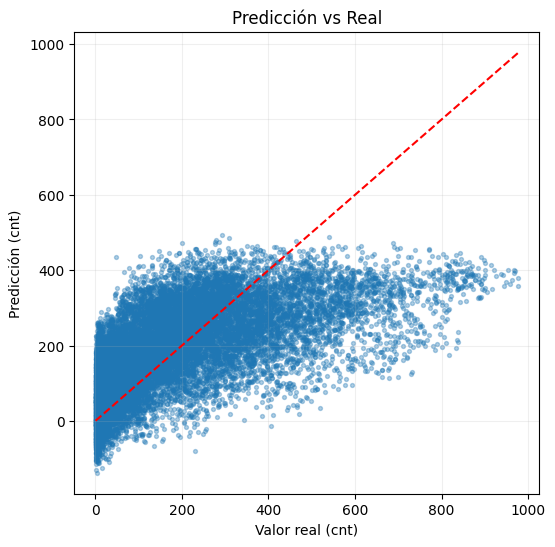

In [58]:
# Esta celda grafica predicción vs valor real.
# Sirve para evaluar visualmente la calidad del ajuste del modelo.
y_pred = np.dot(X, theta)
pyplot.figure(figsize=(6, 6))
pyplot.scatter(y, y_pred, s=8, alpha=0.35)
min_v, max_v = y.min(), y.max()
pyplot.plot([min_v, max_v], [min_v, max_v], 'r--')
pyplot.xlabel('Valor real (cnt)')
pyplot.ylabel('Predicción (cnt)')
pyplot.title('Predicción vs Real')
pyplot.grid(alpha=0.2)

In [59]:
# Esta celda realiza inferencias con dos ejemplos del dataset.
# Sirve para demostrar uso del modelo ya entrenado.
idx1, idx2 = 100, 5000
pred1 = np.dot(X[idx1], theta)
pred2 = np.dot(X[idx2], theta)
print(f'Inferencia 1 -> real: {y[idx1]:.2f}, predicho: {pred1:.2f}')
print(f'Inferencia 2 -> real: {y[idx2]:.2f}, predicho: {pred2:.2f}')

Inferencia 1 -> real: 115.00, predicho: 72.79
Inferencia 2 -> real: 100.00, predicho: 114.43


MSE : 20106.295853
RMSE: 141.796671
R^2 : 0.388858


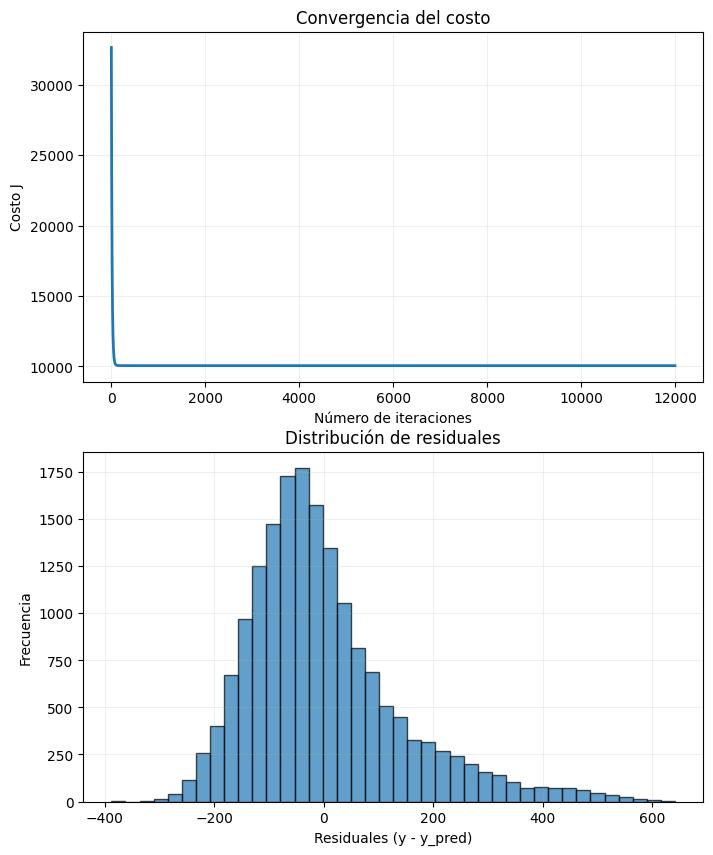

In [60]:
# Esta celda muestra convergencia del costo y métricas finales.
# Sirve para evaluar cuantitativamente el desempeño del modelo.
mse = np.mean((y_pred - y) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - (np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2))

fig = pyplot.figure(figsize=(8, 10))
ax1 = fig.add_subplot(211)
ax1.plot(np.arange(len(J_history)), J_history, lw=2)
ax1.set_xlabel('Número de iteraciones')
ax1.set_ylabel('Costo J')
ax1.set_title('Convergencia del costo')
ax1.grid(alpha=0.2)

ax2 = fig.add_subplot(212)
ax2.hist(y - y_pred, bins=40, edgecolor='k', alpha=0.7)
ax2.set_xlabel('Residuales (y - y_pred)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de residuales')
ax2.grid(alpha=0.2)

print(f'MSE : {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'R^2 : {r2:.6f}')